# Experiment No 4

**Aim:** To build Linear and Logistic Regression models on the Spambase dataset and evaluate their performance using appropriate metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

spambase = fetch_ucirepo(id=94)
df = pd.concat([spambase.data.features, spambase.data.targets], axis=1)
display(df.head(3))

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1


### Preprocessing

In [2]:
X_data = df.drop(columns=['Class'])
y_data = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Linear Regression

,MSE,RMSE,R²,Accuracy
0,0.1069,0.327,0.5523,0.8827


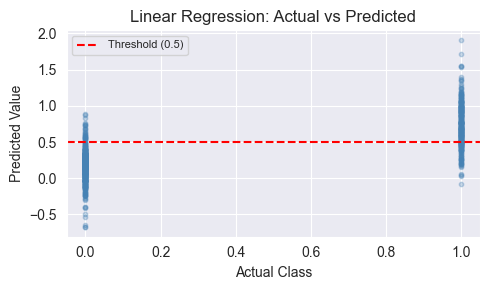

In [3]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr_cont  = lr.predict(X_test_scaled)
y_pred_lr_class = (y_pred_lr_cont >= 0.5).astype(int)

metrics_lr = pd.DataFrame({
    'MSE':      [mean_squared_error(y_test, y_pred_lr_cont)],
    'RMSE':     [np.sqrt(mean_squared_error(y_test, y_pred_lr_cont))],
    'R²':       [r2_score(y_test, y_pred_lr_cont)],
    'Accuracy': [accuracy_score(y_test, y_pred_lr_class)]
}).round(4)
display(metrics_lr)

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(y_test, y_pred_lr_cont, alpha=0.3, s=10, color='steelblue')
ax.axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
ax.set_xlabel('Actual Class'); ax.set_ylabel('Predicted Value')
ax.set_title('Linear Regression: Actual vs Predicted')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Logistic Regression

In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

metrics_log = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_log)],
    'Precision': [precision_score(y_test, y_pred_log)],
    'Recall':    [recall_score(y_test, y_pred_log)],
    'F1-Score':  [f1_score(y_test, y_pred_log)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_log)]
}).round(4)
display(metrics_log)
print(classification_report(y_test, y_pred_log, target_names=['Not Spam', 'Spam']))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.9294,0.9209,0.8981,0.9093,0.9702


              precision    recall  f1-score   support

    Not Spam       0.93      0.95      0.94       558
        Spam       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



### Confusion Matrix & ROC Curve

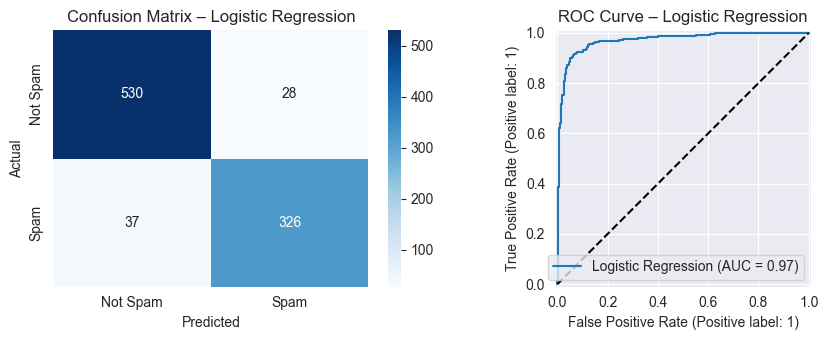

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix – Logistic Regression')

RocCurveDisplay.from_predictions(y_test, y_prob_log, ax=axes[1], name='Logistic Regression')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve – Logistic Regression')

plt.tight_layout(); plt.show()

### Conclusion

Logistic Regression significantly outperforms Linear Regression for binary classification. Linear Regression's continuous outputs require arbitrary thresholding and yield poorer precision/recall, confirming it is unsuitable for classification tasks like spam detection.